# Introduction to Data Analysis and Modeling with Python

In this notebook, we will learn the first steps that data scientists and machine learning engineers use when working with numerical data.

We will practice:

- Loading a dataset
- Inspecting the data
- Cleaning missing values
- Using NumPy and Pandas
- Visualizing data
- Finding correlations
- Filtering data
- Fitting simple models
- Evaluating model performance
- Making predictions

By the end, you should understand the basic workflow used before building machine learning models.

We use:

- `pandas` to load and organize data
- `numpy` for numerical calculations
- `matplotlib` for plotting

In [1]:
# Although there are some exceptions, it is generally a good idea to keep all of your
# imports in one place so that you can easily manage them. Doing so also makes it easy
# to copy all of them at once and paste them into a new notebook you are starting.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the Dataset

The first step in any data analysis project is loading the data.

Our dataset contains yearly GDP values for different countries.

If you open the CSV file, you will notice that the first 4 rows contain extra information that is not part of the actual data table. Because of this, we use `skiprows=4`.

In [2]:
gdp = pd.read_csv("GDP_Data.csv", delimiter=",", skiprows=4)

gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.791061e+09,2.963128e+09,2.983799e+09,3.092179e+09,3.276188e+09,3.395794e+09,2.610039e+09,3.126019e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,...,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,2.055058e+10,1.999814e+10,1.801955e+10,1.889635e+10,1.841886e+10,1.890450e+10,2.014345e+10,1.458314e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,...,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.372444e+11,8.721930e+10,4.984049e+10,6.897277e+10,7.779294e+10,6.930911e+10,5.024137e+10,6.568544e+10,1.067136e+11,NaN


`head()` shows the first few rows of the dataset. This helps us check that the file loaded correctly.

## 2. First Look at the Data

Before doing any analysis, we should understand what kind of data we have.

Important questions:

- How many rows and columns are there?
- What are the column names?
- Which columns are numerical?
- Are there missing values?
- What are the minimum, maximum, mean, and standard deviation?

In [3]:
gdp.shape

(266, 68)

In [4]:
gdp.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       'Unnamed: 67'],
      dtype='str')

In [5]:
gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            132 non-null    float64
 5   1961            134 non-null    float64
 6   1962            136 non-null    float64
 7   1963            136 non-null    float64
 8   1964            136 non-null    float64
 9   1965            147 non-null    float64
 10  1966            150 non-null    float64
 11  1967            153 non-null    float64
 12  1968            158 non-null    float64
 13  1969            158 non-null    float64
 14  1970            167 non-null    float64
 15  1971            170 non-null    float64
 16  1972            170 non-null    float64
 17  1973            170 non-null    float64
 18  1

In [6]:
gdp.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
count,1.320000e+02,1.340000e+02,1.360000e+02,1.360000e+02,1.360000e+02,1.470000e+02,1.500000e+02,1.530000e+02,1.580000e+02,1.580000e+02,...,2.600000e+02,2.580000e+02,2.580000e+02,2.580000e+02,2.580000e+02,2.570000e+02,2.570000e+02,2.510000e+02,2.330000e+02,0.0
mean,7.127083e+10,7.274846e+10,7.639516e+10,8.236303e+10,9.048173e+10,9.182705e+10,1.021722e+11,1.059782e+11,1.111100e+11,1.228652e+11,...,2.540066e+12,2.401519e+12,2.435923e+12,2.611095e+12,2.773995e+12,2.826373e+12,2.739715e+12,3.211353e+12,3.599794e+12,NaN
std,2.135947e+11,2.223876e+11,2.370024e+11,2.549141e+11,2.788048e+11,2.927440e+11,3.205033e+11,3.389517e+11,3.608829e+11,3.971954e+11,...,8.604724e+12,8.165752e+12,8.306057e+12,8.840815e+12,9.410423e+12,9.564901e+12,9.318753e+12,1.072358e+13,1.147950e+13,NaN
min,1.201203e+07,1.159202e+07,9.122751e+06,1.084010e+07,1.271247e+07,1.359393e+07,1.446908e+07,1.583510e+07,1.460000e+07,1.585000e+07,...,3.876097e+07,3.681193e+07,4.162906e+07,4.527661e+07,4.801522e+07,5.412320e+07,5.174657e+07,6.019637e+07,6.034939e+07,NaN
25%,5.288385e+08,5.361919e+08,5.429342e+08,5.687581e+08,5.731182e+08,5.963705e+08,6.499792e+08,6.316797e+08,6.583150e+08,7.116598e+08,...,9.034786e+09,8.752203e+09,8.620796e+09,9.319389e+09,1.002804e+10,1.038167e+10,9.754600e+09,1.150202e+10,1.567158e+10,NaN
50%,3.040214e+09,2.965945e+09,3.049474e+09,3.569338e+09,3.432187e+09,3.120871e+09,3.549759e+09,3.384063e+09,3.950426e+09,4.526894e+09,...,5.339986e+10,4.966768e+10,4.980725e+10,5.400064e+10,5.614400e+10,6.028350e+10,5.370680e+10,6.568544e+10,8.227481e+10,NaN
75%,3.103045e+10,3.128542e+10,3.161860e+10,3.617095e+10,3.401420e+10,2.851910e+10,3.082854e+10,3.108639e+10,3.451917e+10,3.766365e+10,...,5.478564e+11,5.020845e+11,5.057567e+11,5.369244e+11,5.524163e+11,5.439767e+11,5.470542e+11,7.400410e+11,9.911146e+11,NaN
max,1.384857e+12,1.449221e+12,1.550815e+12,1.671447e+12,1.830492e+12,1.994103e+12,2.164118e+12,2.302577e+12,2.484674e+12,2.740499e+12,...,7.975652e+13,7.521506e+13,7.648645e+13,8.144205e+13,8.650222e+13,8.772810e+13,8.521515e+13,9.688240e+13,1.005620e+14,NaN


## 3. Finding Missing Values

Real-world datasets often contain missing values.

In Python, missing numerical values usually appear as `NaN`, which means “Not a Number.”

Before cleaning the data, we should check where those missing values are.

In [7]:
gdp.isna().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              134
                 ... 
2019                9
2020                9
2021               15
2022               33
Unnamed: 67       266
Length: 68, dtype: int64

The dataset also contains a fully empty column at the end called something like `Unnamed: 67`.

If we use `dropna()` immediately, Python will remove every row because every row has a missing value in that empty column.

So we first remove fully empty columns, then remove rows that still contain missing values.

In [8]:
# Drop columns that are completely empty
gdp_clean = gdp.dropna(axis="columns", how="all")

# Drop rows that still contain missing values
gdp_clean = gdp_clean.dropna()

# Check result
gdp_clean.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,...,9.859871e+11,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,...,8.339481e+11,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11
13,Australia,AUS,GDP (current US$),NY.GDP.MKTP.CD,1.860656e+10,1.968288e+10,1.992256e+10,2.153984e+10,2.380112e+10,2.597616e+10,...,1.576330e+12,1.467590e+12,1.350580e+12,1.206563e+12,1.326467e+12,1.428267e+12,1.392219e+12,1.326945e+12,1.552703e+12,1.675419e+12
14,Austria,AUT,GDP (current US$),NY.GDP.MKTP.CD,6.592694e+09,7.311750e+09,7.756110e+09,8.374175e+09,9.169984e+09,9.994071e+09,...,4.301910e+11,4.425848e+11,3.819711e+11,3.958374e+11,4.172612e+11,4.549912e+11,4.446212e+11,4.352252e+11,4.803684e+11,4.714001e+11
16,Burundi,BDI,GDP (current US$),NY.GDP.MKTP.CD,1.960000e+08,2.030000e+08,2.135000e+08,2.327500e+08,2.607500e+08,1.589950e+08,...,2.451607e+09,2.705783e+09,3.104004e+09,2.644488e+09,2.723587e+09,2.667182e+09,2.576519e+09,2.649680e+09,2.775799e+09,3.073415e+09


In [9]:
gdp_clean.shape

(122, 67)

In [10]:
gdp_clean.isna().sum()

Country Name      0
Country Code      0
Indicator Name    0
Indicator Code    0
1960              0
                 ..
2018              0
2019              0
2020              0
2021              0
2022              0
Length: 67, dtype: int64

## 4. Basic Statistics

Now that the data has been cleaned, we can calculate basic statistics.

We will start by analyzing GDP values for one year.

In [11]:
year = "2022"

gdp_2022 = gdp_clean[year]

print("Mean GDP:", np.mean(gdp_2022))
print("Median GDP:", np.median(gdp_2022))
print("Standard deviation:", np.std(gdp_2022))

Mean GDP: 6161324302828.015
Median GDP: 351889022032.789
Standard deviation: 15130374629831.71


In [12]:
gdp_clean[year].describe()

count    1.220000e+02
mean     6.161324e+12
std      1.519277e+13
min      9.485585e+08
25%      2.837043e+10
50%      3.518890e+11
75%      2.047347e+12
max      1.005620e+14
Name: 2022, dtype: float64

The mean gives the average value.

The median gives the middle value.

The standard deviation tells us how spread out the values are.

## 5. Visualizing One Variable

A histogram shows the distribution of one variable.

Here, we will look at how GDP values are distributed across countries.

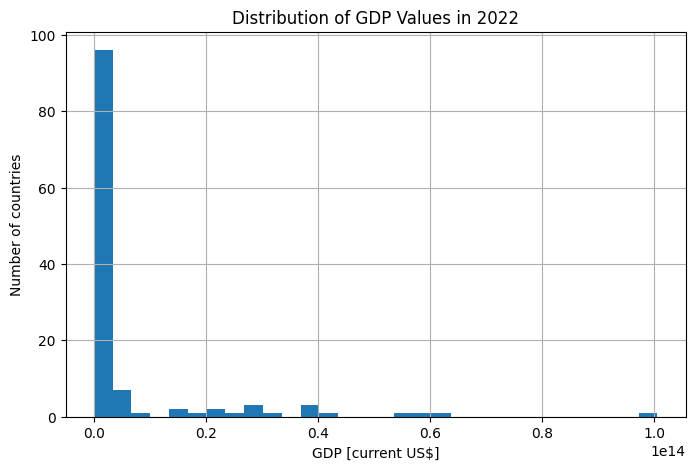

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(gdp_clean[year], bins=30)
plt.xlabel("GDP [current US$]")
plt.ylabel("Number of countries")
plt.title(f"Distribution of GDP Values in {year}")
plt.grid(True)
plt.show()

Many real-world datasets have values that are very spread out. A few countries may have extremely high GDP values compared to others.

A log scale can sometimes make the plot easier to interpret.

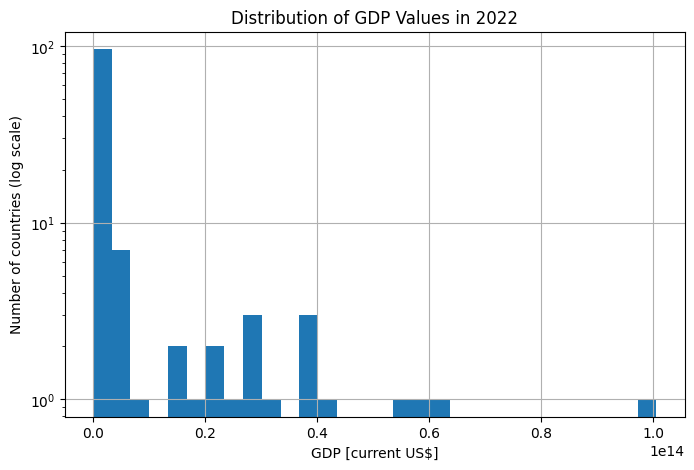

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(gdp_clean[year], bins=30)
plt.yscale("log")
plt.xlabel("GDP [current US$]")
plt.ylabel("Number of countries (log scale)")
plt.title(f"Distribution of GDP Values in {year}")
plt.grid(True)
plt.show()

## 6. Filtering Data with Masks

Sometimes we only want to look at rows that meet a condition.

For example, we can find countries with GDP above 1 trillion dollars.

This type of condition is called a Boolean mask.

In [15]:
threshold = 1e12  # 1 trillion dollars

high_gdp_mask = gdp_clean[year] > threshold
high_gdp_countries = gdp_clean[high_gdp_mask]

high_gdp_countries[["Country Name", year]]

,Country Name,2022
1,Africa Eastern and Southern,1.169484e+12
13,Australia,1.675419e+12
29,Brazil,1.920096e+12
35,Canada,2.139840e+12
40,China,1.796317e+13
61,East Asia & Pacific (excluding high income),2.118932e+13
62,Early-demographic dividend,1.402951e+13
63,East Asia & Pacific,3.065525e+13
68,Euro area,1.404089e+13
70,Spain,1.397509e+12


In [16]:
print("Countries above threshold:", len(high_gdp_countries))
print("Total countries:", len(gdp_clean))
print("Fraction:", len(high_gdp_countries) / len(gdp_clean))

Countries above threshold: 43
Total countries: 122
Fraction: 0.3524590163934426


## 7. Plotting GDP Over Time for One Country

Now we will select one country and plot its GDP over time.

This requires extracting the year columns and the GDP values for that country.

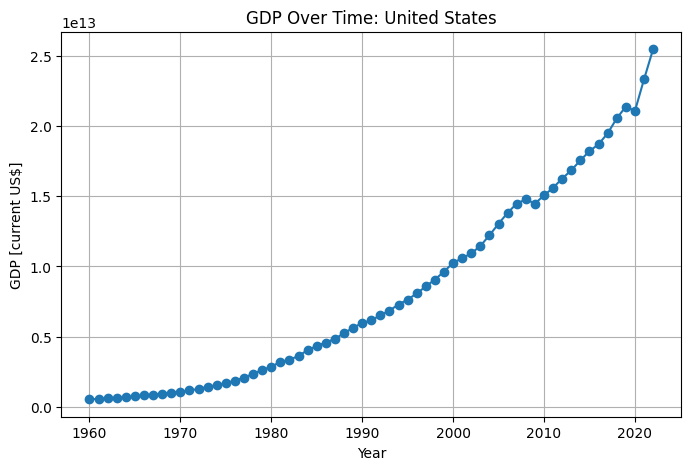

In [17]:
country_name = "United States"

country_data = gdp_clean[gdp_clean["Country Name"] == country_name]

year_columns = gdp_clean.columns[4:]
years = year_columns.astype(int)

gdp_values = country_data.iloc[0, 4:].values.astype(float)

plt.figure(figsize=(8, 5))
plt.plot(years, gdp_values, marker="o")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Over Time: {country_name}")
plt.grid(True)
plt.show()

## 8. Comparing Multiple Countries

Now we will compare GDP over time for several countries.

In [19]:
print(gdp_clean["Country Name"].unique()[:20])

<StringArray>
['Africa Eastern and Southern',  'Africa Western and Central',
                   'Australia',                     'Austria',
                     'Burundi',                     'Belgium',
                       'Benin',                'Burkina Faso',
                  'Bangladesh',                'Bahamas, The',
                      'Belize',                     'Bermuda',
                     'Bolivia',                      'Brazil',
                    'Botswana',    'Central African Republic',
                      'Canada',                       'Chile',
                       'China',               'Cote d'Ivoire']
Length: 20, dtype: str


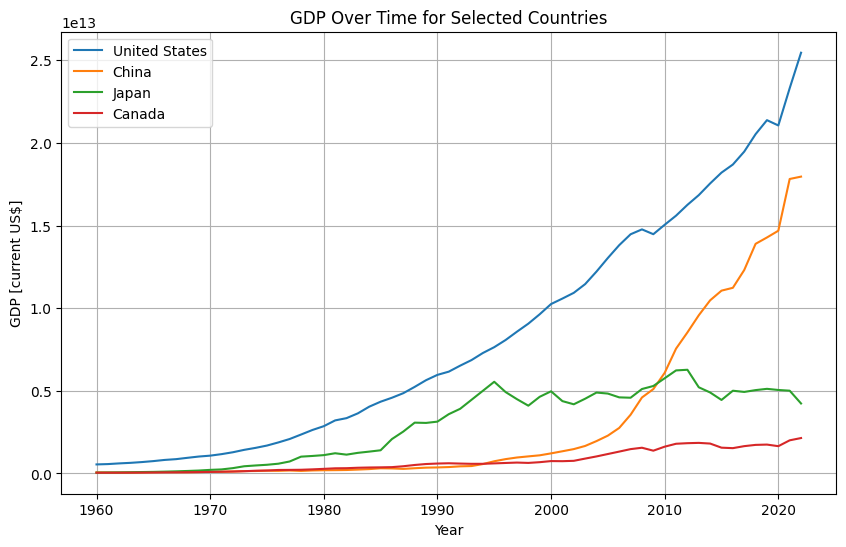

In [21]:
countries = ["United States", "China", "Japan", "Canada"]

plt.figure(figsize=(10, 6))

for country in countries:
    country_data = gdp_clean[gdp_clean["Country Name"] == country]

    if country_data.empty:
        print(f"⚠️ Warning: {country} not found in dataset")
        continue

    gdp_values = country_data.iloc[0, 4:].values.astype(float)
    plt.plot(years, gdp_values, label=country)

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title("GDP Over Time for Selected Countries")
plt.legend()
plt.grid(True)
plt.show()

When values are very different in size, a log scale can make comparison easier.

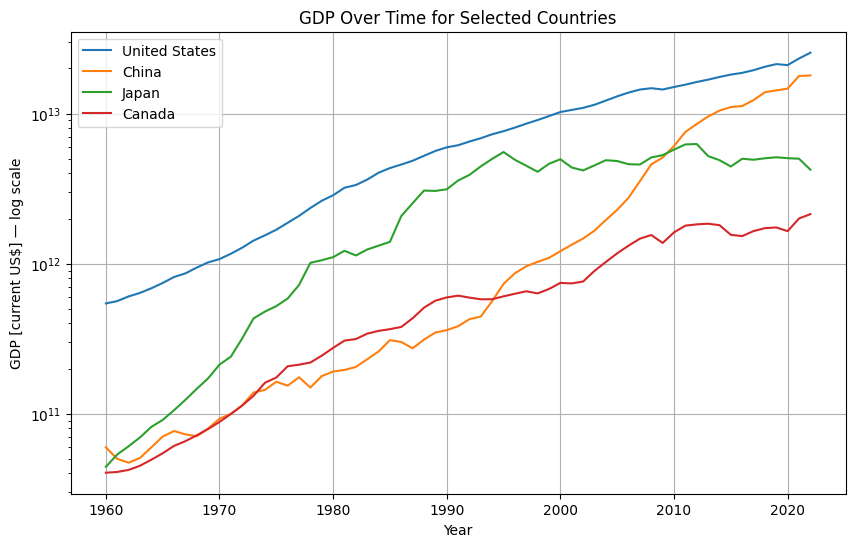

In [22]:
plt.figure(figsize=(10, 6))

for country in countries:
    country_data = gdp_clean[gdp_clean["Country Name"] == country]
    gdp_values = country_data.iloc[0, 4:].values.astype(float)
    plt.plot(years, gdp_values, label=country)

plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("GDP [current US$] — log scale")
plt.title("GDP Over Time for Selected Countries")
plt.legend()
plt.grid(True)
plt.show()

## 9. Correlation

Correlation measures how strongly two numerical variables are related.

A correlation close to 1 means the variables tend to increase together.

A correlation close to -1 means one variable tends to decrease as the other increases.

A correlation close to 0 means there is not a strong linear relationship.

In [23]:
selected_years = ["2000", "2005", "2010", "2015", "2020", "2022"]

corr_matrix = gdp_clean[selected_years].corr()

corr_matrix

,2000,2005,2010,2015,2020,2022
2000,1.000000,0.997969,0.972219,0.945335,0.935505,0.921715
2005,0.997969,1.000000,0.982709,0.959609,0.950634,0.938604
2010,0.972219,0.982709,1.000000,0.994042,0.989375,0.984036
2015,0.945335,0.959609,0.994042,1.000000,0.999122,0.997502
2020,0.935505,0.950634,0.989375,0.999122,1.000000,0.999055
2022,0.921715,0.938604,0.984036,0.997502,0.999055,1.000000


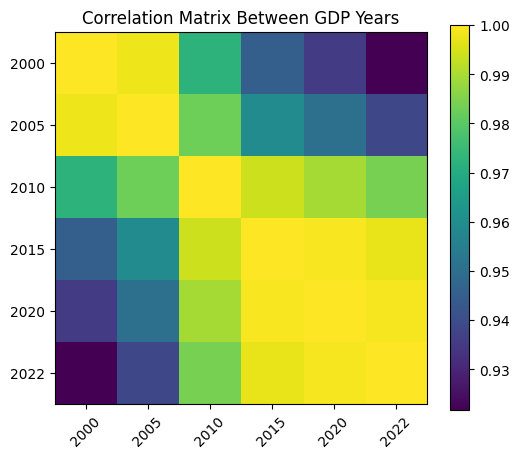

In [24]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(selected_years)), selected_years, rotation=45)
plt.yticks(range(len(selected_years)), selected_years)
plt.title("Correlation Matrix Between GDP Years")
plt.show()

## 10. Scatter Plots

Scatter plots are useful for comparing two variables.

Here, we compare GDP in two different years.

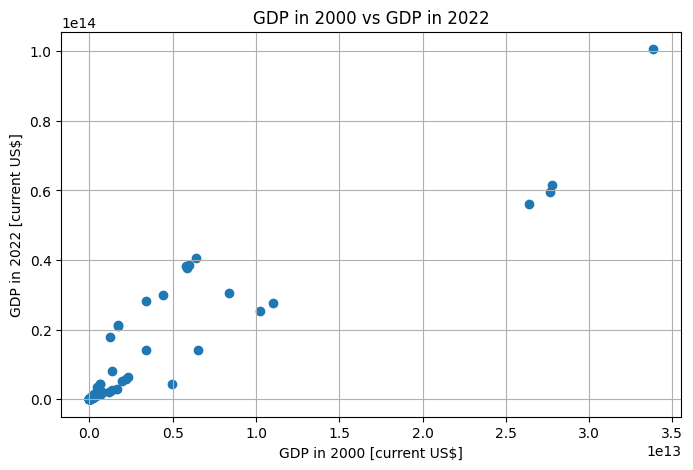

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(gdp_clean["2000"], gdp_clean["2022"])
plt.xlabel("GDP in 2000 [current US$]")
plt.ylabel("GDP in 2022 [current US$]")
plt.title("GDP in 2000 vs GDP in 2022")
plt.grid(True)
plt.show()

## 11. Introduction to Modeling

A model is a simplified way to describe a relationship in data.

For example, we might ask:

Can we use the year to predict GDP?

This is the basic idea behind machine learning:

Use data to learn a pattern, then use that pattern to make predictions.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 12. Linear Regression

A linear regression model assumes the data follows a straight-line pattern.

In [29]:
country_name = "United States"

country_data = gdp_clean[gdp_clean["Country Name"] == country_name]

# Convert year columns to a NumPy array
years = gdp_clean.columns[4:].astype(int).to_numpy()

# X must be 2D for sklearn
X = years.reshape(-1, 1)

# y is the GDP values for the selected country
y = country_data.iloc[0, 4:].values.astype(float)

linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)

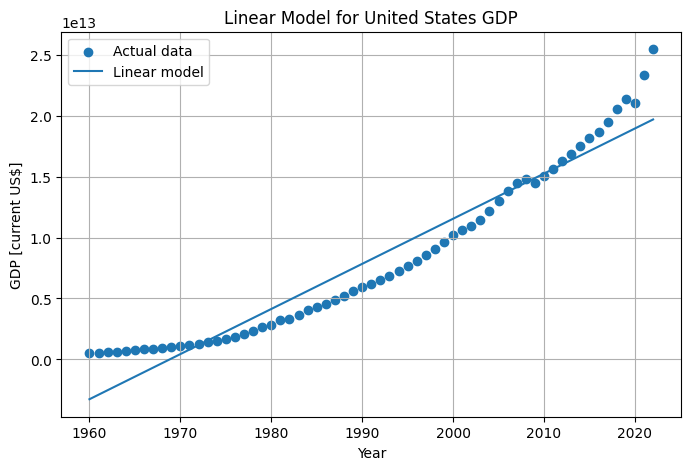

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, label="Linear model")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Linear Model for {country_name} GDP")
plt.legend()
plt.grid(True)
plt.show()

## 13. Evaluating the Linear Model

We need to measure how well the model fits the data.

Two common metrics are:

- RMSE: average prediction error
- R²: how much variation in the data is explained by the model

In [31]:
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
r2_linear = r2_score(y, y_pred_linear)

print("Linear RMSE:", rmse_linear)
print("Linear R²:", r2_linear)

Linear RMSE: 1843037678131.5547
Linear R²: 0.930348948642023


## 14. Polynomial Regression

A straight line may not describe the data well.

A polynomial model can curve, so it may fit some patterns better.

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X, y)

y_pred_poly = poly_model.predict(X)

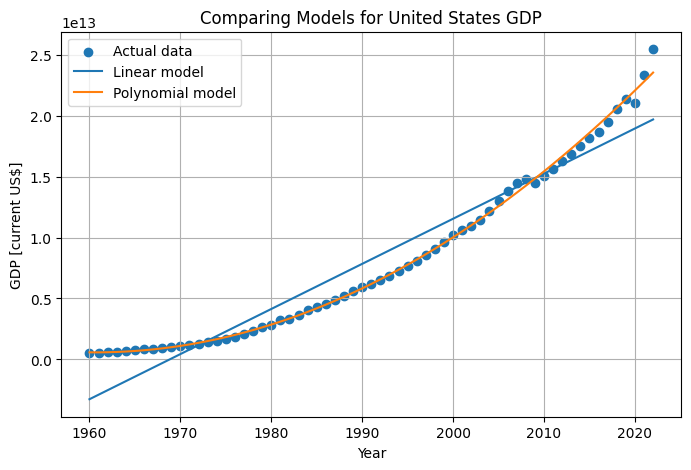

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, label="Linear model")
plt.plot(years, y_pred_poly, label="Polynomial model")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Comparing Models for {country_name} GDP")
plt.legend()
plt.grid(True)
plt.show()

## 15. Comparing Models

Now we compare the linear model and the polynomial model using RMSE and R².

In [34]:
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
r2_poly = r2_score(y, y_pred_poly)

print("Linear RMSE:", rmse_linear)
print("Polynomial RMSE:", rmse_poly)

print("Linear R²:", r2_linear)
print("Polynomial R²:", r2_poly)

Linear RMSE: 1843037678131.5547
Polynomial RMSE: 370864977548.12396
Linear R²: 0.930348948642023
Polynomial R²: 0.9971797286573196


A lower RMSE means the model has smaller prediction errors.

A higher R² usually means the model explains more of the variation in the data.

However, a model that fits old data very well is not always better at predicting new data.

## 16. Making Predictions

Now we can use our models to predict GDP in a future year.

In [35]:
future_year = np.array([[2030]])

linear_prediction = linear_model.predict(future_year)
poly_prediction = poly_model.predict(future_year)

print("Linear model prediction for 2030:", linear_prediction[0])
print("Polynomial model prediction for 2030:", poly_prediction[0])

Linear model prediction for 2030: 22660298340090.875
Polynomial model prediction for 2030: 29928986899212.0


Question:

Do these predictions seem reasonable?

What assumptions are we making when we predict the future using old data?

## 17. Training and Testing

A model can look good on the data it was trained on but perform poorly on new data.

To test this, we can train the model on earlier years and test it on later years.

In [36]:
train_mask = years <= 2010
test_mask = years > 2010

X_train = years[train_mask].reshape(-1, 1)
y_train = y[train_mask]

X_test = years[test_mask].reshape(-1, 1)
y_test = y[test_mask]

In [37]:
test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

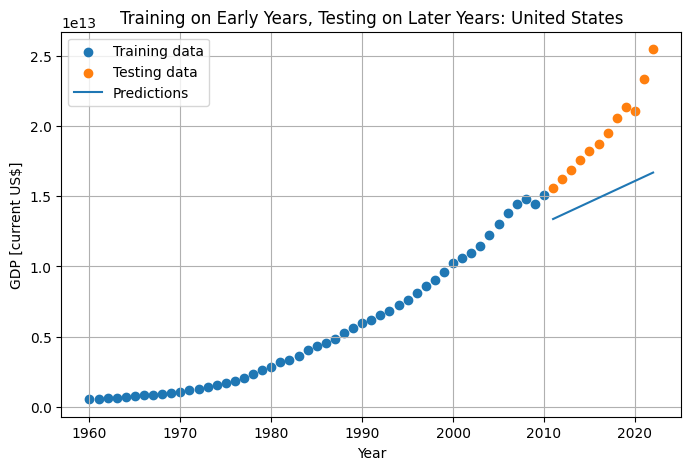

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, label="Testing data")
plt.plot(X_test, test_predictions, label="Predictions")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Training on Early Years, Testing on Later Years: {country_name}")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test RMSE: 4862482645490.22
Test R²: -1.9534028421591256


This is closer to how machine learning models are evaluated.

We do not only care about how well a model fits old data.

We care about how well it predicts new data.

## 18. Your Turn

Choose a different country and repeat the analysis.

Try to answer:

1. What country did you choose?
2. What does the GDP trend look like?
3. Does a linear or polynomial model fit better?
4. What does the model predict for 2030?
5. Do you trust the prediction? Why or why not?

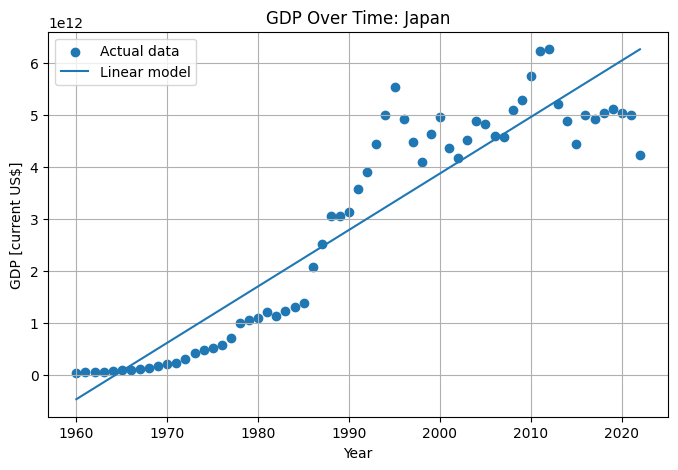

In [40]:
chosen_country = "Japan"

country_data = gdp_clean[gdp_clean["Country Name"] == chosen_country]

X = years.reshape(-1, 1)
y = country_data.iloc[0, 4:].values.astype(float)

student_linear_model = LinearRegression()
student_linear_model.fit(X, y)

student_predictions = student_linear_model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(years, y, label="Actual data")
plt.plot(years, student_predictions, label="Linear model")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Over Time: {chosen_country}")
plt.legend()
plt.grid(True)
plt.show()

## Final Reflection

In this notebook, we practiced the basic workflow used in data analysis and machine learning:

1. Load data
2. Inspect data
3. Clean missing values
4. Visualize patterns
5. Look for relationships
6. Filter useful subsets
7. Fit a model
8. Evaluate the model
9. Make predictions
10. Question whether the predictions make sense

This workflow is the foundation for more advanced machine learning.